# Пример

<Axes: >

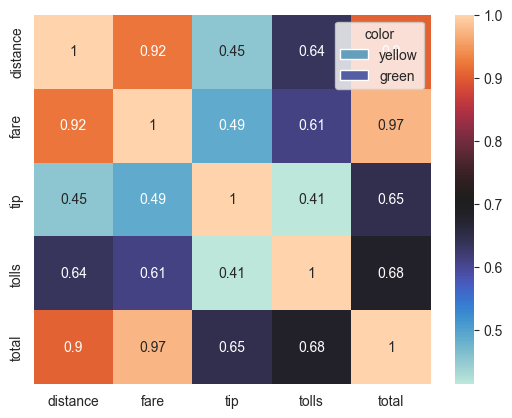

In [14]:
import pandas as pd # Импортируем библиотеку для работы с датасетом
import seaborn as sns # Импортируем библиотеки для работы с визуализацией
import matplotlib.pyplot as plt

sns.set_style("whitegrid") # Устанавливаем тему для графиков
sns.set_palette(sns.color_palette("icefire")) # Устанавливаем единую па-литру для всех визуализаций
df = sns.load_dataset("taxis") # Загружаем датасет о поездках на такси
df.head() # Проверяем загрузку

df.select_dtypes(include=['object']).describe() # Описательная статистика для категориальных данных
# df.select_dtypes() обращается к переменным определенного типа
# Метод .describe() выводит описательную статистику по каждой переменной

df.select_dtypes(include=['float64', 'int64']).describe() # Описательная статистика для числовых данных

df.dtypes # Типы данных датафрейма можно посмотреть при помощи команды .dtypes

# Визуализация данных в разведовательном анализе данных начинается с по-строения распределения при помощи гистограмм
# Гистограмма -  визуальный элемент показывающий, с какой частотой один и тот же параметр принимает определенные значения.
# Рассмотрим построение на примере показателя payment (вид оплаты)
df['payment'].value_counts() # метод .value_counts() выводит частоту для каждого значения переменной

# Построение гистограммы
sns.countplot(df, x='payment')
# По данному графику можем сделать вывод, что кредитными картами пассажиры пользуются в 2 раза чаще

# Также при построении гистограмм можно добавлять различные срезы в данных при помощи атрибута hue = <Переменная> 
sns.countplot(df, x='payment', hue = 'color')
# В данном случае можем сделать вывод, что чаще всего к пассажирам приез-жает желтая машина и при окончании поездки они расплачиваются картой

# Построим гистограмму для числовой переменной total, параметр bins задает число разбиений
sns.histplot(df, x='total', bins = 30)
# По данной диаграмме можем сделать вывод, что распределение ассиметрич-ное, большинство заказов такси стоят до 25$ 
# Длинный хвост у распределения может указывать на наличие выбросов, либо поездку на большое расстояние

# Для исследования взаимосвязей рассмотрим визуализацию тепловой карты (heatmap)
# Данные для построения диаграммы - коэффициенты корреляции между перемен-ными, вычисляется при помощи функции .corr()
# Параметры annot и cmap добавляют подписи и меняют цвет
sns.heatmap(df[['distance','fare','tip','tolls','total']].corr(), annot=True, cmap="icefire")
# По графику заметим, что обратной корреляции в данных не наблюдается
# Красный цвет означает сильную взаимосвязь, голубой - более слабую

<Axes: xlabel='fare', ylabel='distance'>

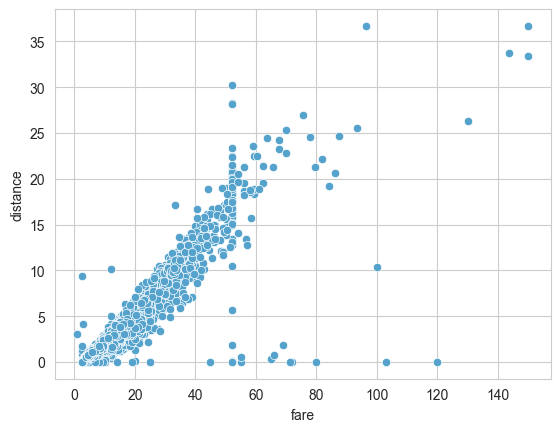

In [15]:
# Рассмотрим более детально взаимосвязь переменных fare (стоимость поезд-ки) и distance (дистанция) (коэффициент корреляции составляет 0,97 - силь-ная корреляция)
# Для этого построим диаграмму рассеяния, где по шкале х - стоимость по-ездки, по у - дистанция
sns.scatterplot(df, x="fare", y="distance")
# График подтвержает взаимосвязь: чем больше дистанция поездки, тем выше ее стоимость

total
pickup_borough pickup_zone                            
Queens         East Flushing                 90.500000
               Flushing Meadows-Corona Park  75.560000
               JFK Airport                   55.336954
               Douglaston                    53.730000
               Maspeth                       52.040000
Bronx          Bronx Park                    50.330000
Queens         Cambria Heights               46.903333
Bronx          Crotona Park East             44.870000
Queens         Howard Beach                  44.800000
Brooklyn       Sunset Park West              43.086667

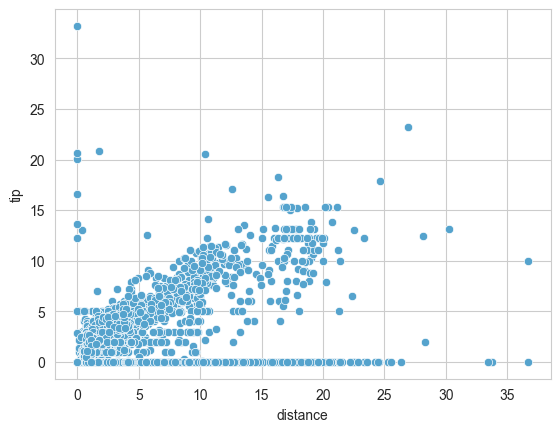

In [16]:
# Также рассмотрим взаимосвязь переменных tip (чаевые) и distance (дистан-ция) (коэффициент корреляции составляет 0,45 - средняя корреляция)
sns.scatterplot(df, x="distance", y="tip")
# По графику видно, что наблюдения располагаются более разрозненно, также присутсвует много нулевых значений

# Например, рассмотрим медианное значение чаевых, оставляемых в такси раз-ного цвета
# Для этого в параметр by функции groupby передаем столбец color, по кото-рому будет происходить разделение на группы (желтые, зеленые)
# .median() задает агреггирующую функцию
df[['color','tip']].groupby(by= 'color').median()

# Также в groupby можно передавать несколько столбцов
# Посмотрим, какая средняя стоимость поездки в топ-10 зонах и районах
# Функция sort_values сортирует значения, а параметр ascending задает направление сортировки
df[['pickup_borough','pickup_zone','total']].groupby(by=['pickup_borough','pickup_zone']).mean().sort_values(by='total', ascending=False).head(10)

# Задание 1

## 1. Скачать данные по ссылке https://www.kaggle.com/datasets/joannanplkrk/dirty-data-to-clean-whats-wrong-with-this-dataset?select=animal_data_dirty1.csv;

## 2. Загрузить в python при помощи функции pd.read_csv('<Название файла>');

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

# Загружаем данные с правильным разделителем
df_animals = pd.read_csv('animal_data_dirty1.csv', sep=';')

FileNotFoundError: [Errno 2] No such file or directory: 'animal_data_dirty1.csv'

## 3. Выводим основные числовые характеристики

In [ ]:
print("Первые 5 строк данных:")
print(df_animals.head())

print("\nРазмер датасета:", df_animals.shape)
print("\nИнформация о данных:")
df_animals.info()

print("\nОсновные числовые характеристики (до очистки):")
# Выбираем только числовые колонки для описания
numeric_cols = df_animals.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 0:
    print(df_animals[numeric_cols].describe())
else:
    print("Нет числовых колонок для описания")

Первые 5 строк данных:
       Animal type Country  Weight kg  Body Length cm          Gender  \
0              NaN     NaN        NaN             NaN             NaN   
1              NaN     NaN        NaN             NaN             NaN   
2   European bison  Poland      930.0           335.0            male   
3   European bison  Poland      909.0           311.0  not determined   
4  European bison™  Poland      581.0           277.0          female   

   Animal code   Latitude  Longitude Animal name Observation date  \
0          NaN        NaN        NaN         NaN       03.01.2024   
1          NaN        NaN        NaN         NaN       03.02.2024   
2          NaN  52.828845  23.820144       Szefu       01.03.2024   
3          NaN  52.830509  23.826849         NaN       01.03.2024   
4          NaN  52.834109  23.807093         NaN       01.03.2024   

  Data compiled by  
0    James Johnson  
1    James Johnson  
2     Anne Anthony  
3     Anne Anthony  
4     Anne Anthony

## 4. Профилирование данных и очистка


2.1 Пропущенные значения:
Animal type           20
Country               12
Weight kg             27
Body Length cm        27
Gender                19
Animal code         1011
Latitude              98
Longitude             98
Animal name          959
Observation date       0
Data compiled by       0
dtype: int64


<Figure size 1200x600 with 0 Axes>

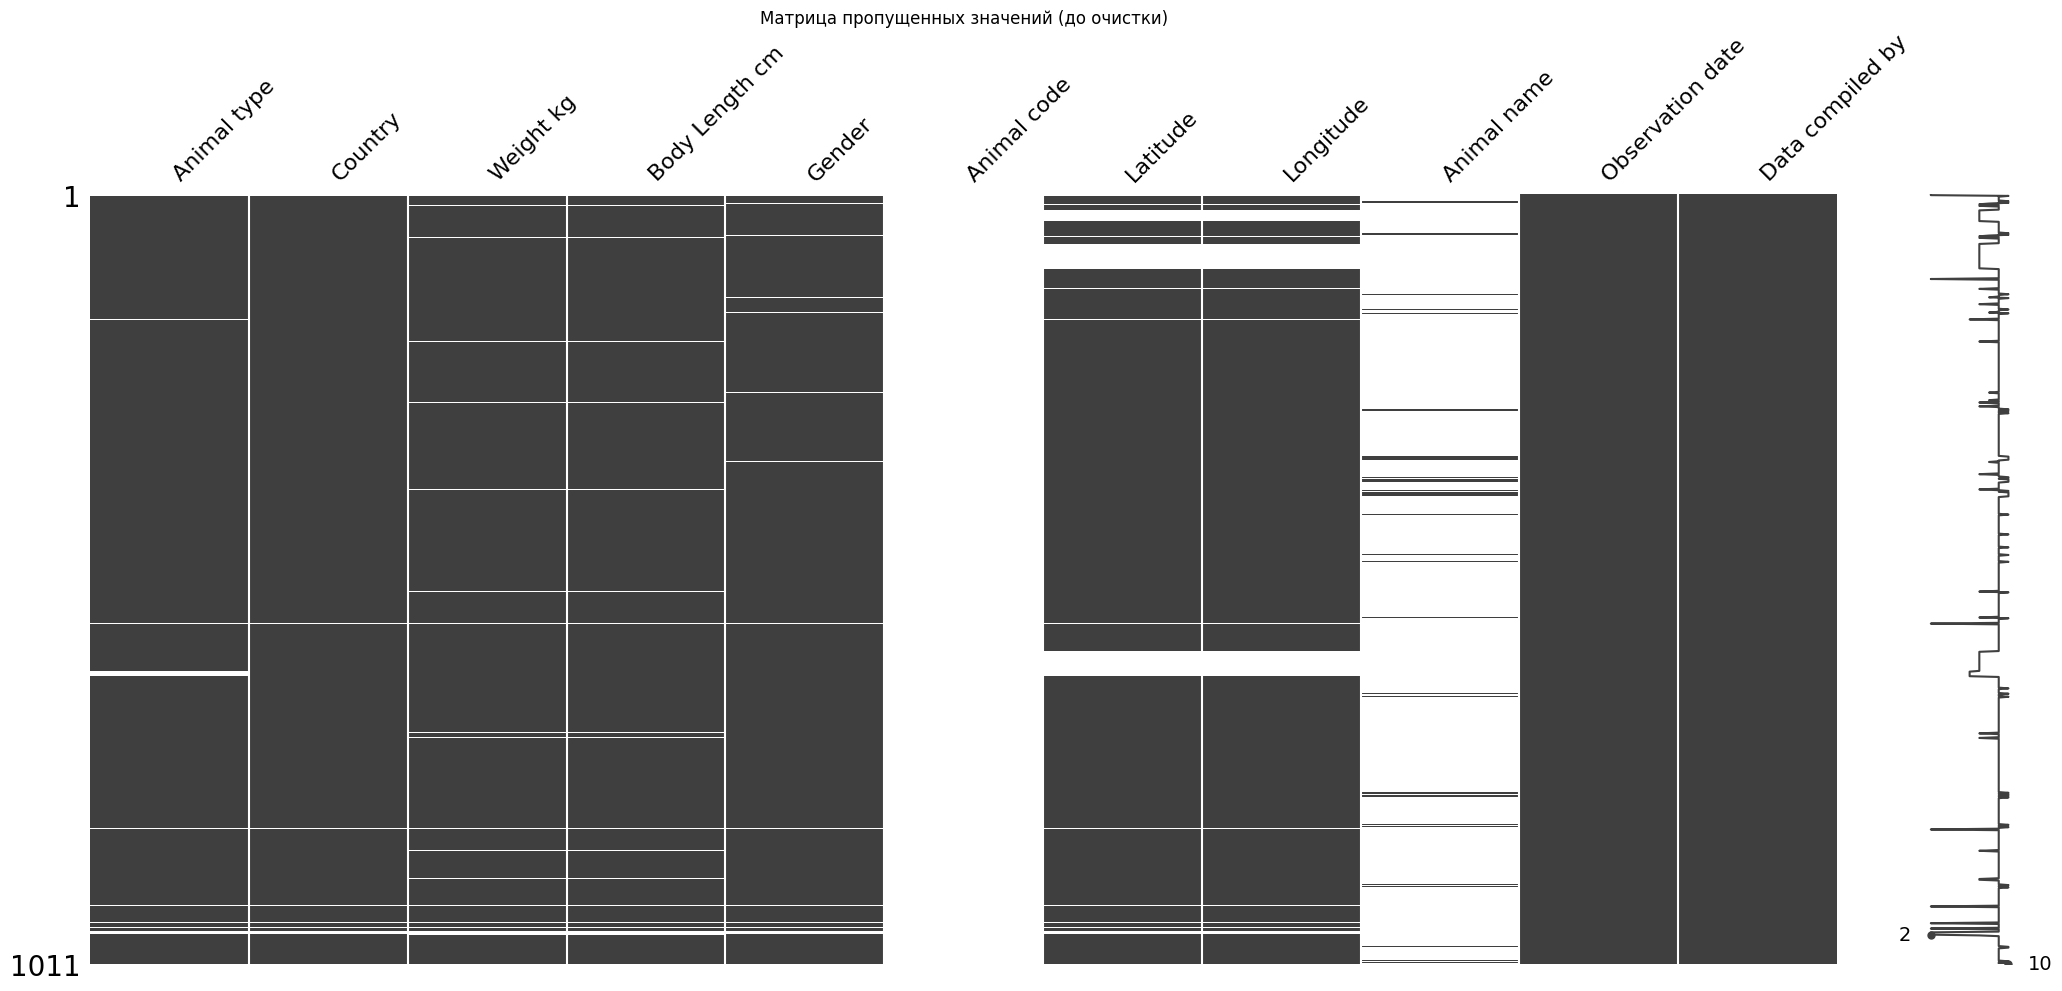


Пропущенные значения после заполнения:
Animal type            0
Country                0
Weight kg              0
Body Length cm         0
Gender                 0
Animal code         1011
Latitude               0
Longitude              0
Animal name            0
Observation date       0
Data compiled by       0
dtype: int64

2.2 Дубликаты:
Количество дублирующихся строк до удаления: 167
Количество дублирующихся строк после удаления: 0

2.3 Преобразование типов данных:
Типы данных после преобразования:
Animal type             str
Country                 str
Weight kg           float64
Body Length cm      float64
Gender                  str
Animal code         float64
Latitude            float64
Longitude           float64
Animal name             str
Observation date        str
Data compiled by        str
dtype: object

2.4 Выбросы:
Weight kg: 134 выбросов (границы: [-0.60, 1.80])


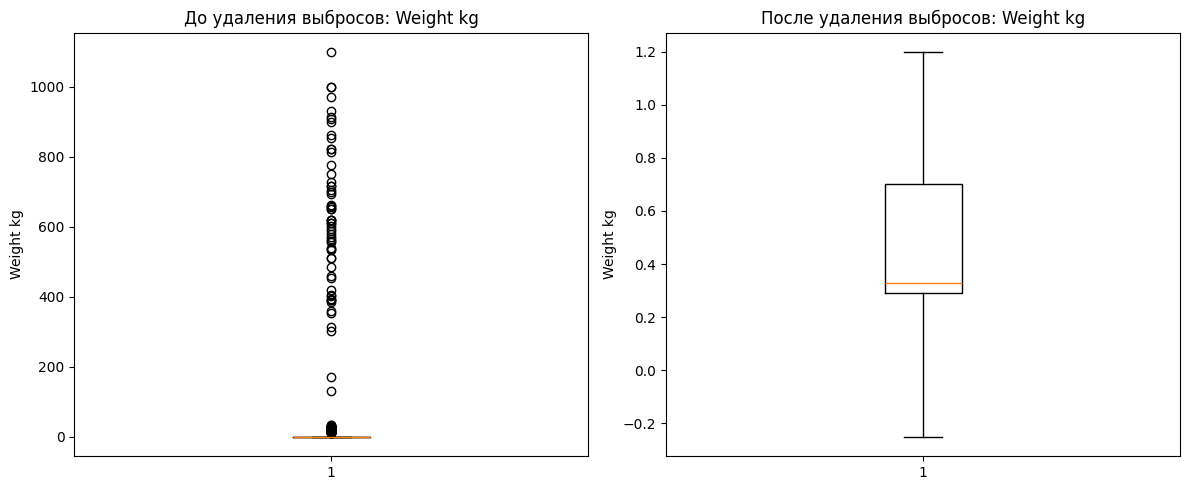

Body Length cm: 26 выбросов (границы: [14.50, 26.50])


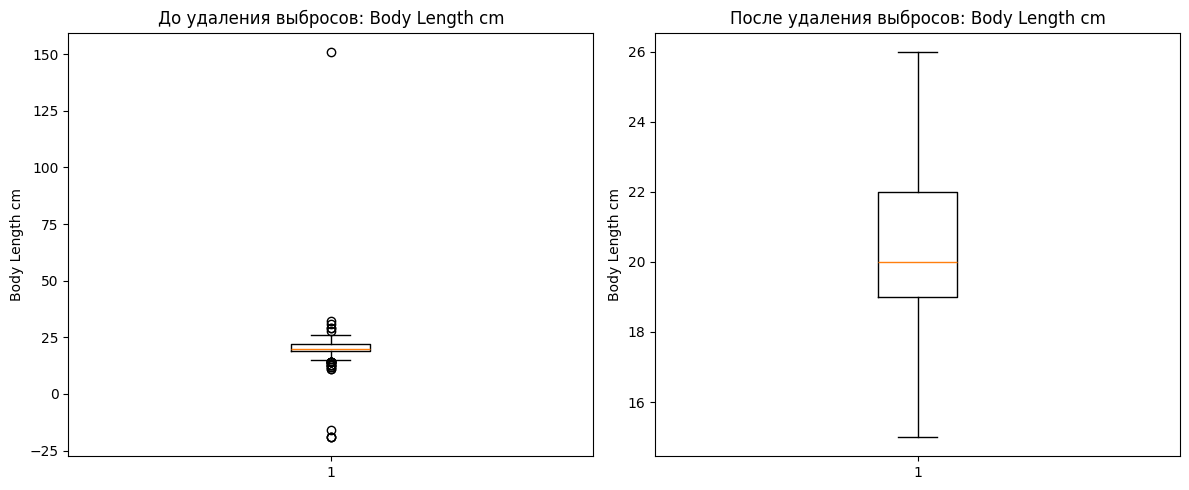

Animal code: 0 выбросов (границы: [nan, nan])
Latitude: 2 выбросов (границы: [45.40, 52.83])


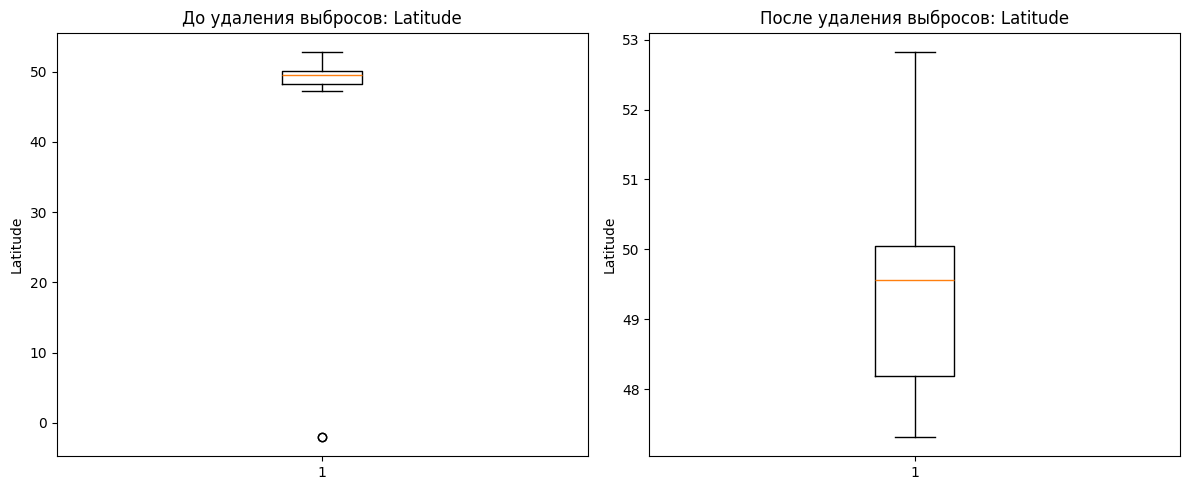

Longitude: 0 выбросов (границы: [5.94, 28.36])


In [ ]:
# Анализ пропущенных значений
print("\n2.1 Пропущенные значения:")
print(df_animals.isnull().sum())

# Визуализация пропущенных значений
plt.figure(figsize=(12, 6))
msno.matrix(df_animals)
plt.title('Матрица пропущенных значений (до очистки)')
plt.show()

# Заполнение пропущенных значений (исправленная версия без inplace)
# Для числовых колонок используем медиану
numeric_columns = df_animals.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_columns:
    df_animals[col] = df_animals[col].fillna(df_animals[col].median())

# Для категориальных колонок используем моду или 'Unknown'
categorical_columns = df_animals.select_dtypes(include=['object']).columns.tolist()
for col in categorical_columns:
    mode_value = df_animals[col].mode()
    if len(mode_value) > 0:
        df_animals[col] = df_animals[col].fillna(mode_value[0])
    else:
        df_animals[col] = df_animals[col].fillna('Unknown')

print("\nПропущенные значения после заполнения:")
print(df_animals.isnull().sum())

# Поиск и удаление дубликатов
print("\n2.2 Дубликаты:")
print(f"Количество дублирующихся строк до удаления: {df_animals.duplicated().sum()}")
df_animals = df_animals.drop_duplicates()
print(f"Количество дублирующихся строк после удаления: {df_animals.duplicated().sum()}")

# Преобразование типов данных
print("\n2.3 Преобразование типов данных:")

# Пытаемся преобразовать потенциально числовые колонки
for col in df_animals.columns:
    # Пробуем преобразовать в числовой формат
    try:
        df_animals[col] = pd.to_numeric(df_animals[col], errors='ignore')
    except:
        pass

print("Типы данных после преобразования:")
print(df_animals.dtypes)

# Обработка выбросов для числовых колонок
print("\n2.4 Выбросы:")

# Функция для обнаружения выбросов методом IQR
def find_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Анализируем выбросы для числовых колонок
numeric_columns = df_animals.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_columns) > 0:
    for col in numeric_columns:
        n_outliers, lower, upper = find_outliers_iqr(df_animals, col)
        print(f"{col}: {n_outliers} выбросов (границы: [{lower:.2f}, {upper:.2f}])")
        
        if n_outliers > 0:
            # Визуализация выбросов
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            
            # До удаления выбросов
            axes[0].boxplot(df_animals[col].dropna())
            axes[0].set_title(f'До удаления выбросов: {col}')
            axes[0].set_ylabel(col)
            
            # Удаляем выбросы
            df_animals = df_animals[(df_animals[col] >= lower) & (df_animals[col] <= upper)]
            
            # После удаления выбросов
            axes[1].boxplot(df_animals[col].dropna())
            axes[1].set_title(f'После удаления выбросов: {col}')
            axes[1].set_ylabel(col)
            
            plt.tight_layout()
            plt.show()
else:
    print("Нет числовых колонок для анализа выбросов")

## 5. Поиск противоречий в данных

In [ ]:
# Проверяем различные противоречия в зависимости от наличия колонок
if 'Weight kg' in df_animals.columns:
    neg_weight = df_animals[df_animals['Weight kg'] < 0].shape[0]
    print(f"Записей с отрицательным весом: {neg_weight}")
    df_animals = df_animals[df_animals['Weight kg'] >= 0]

if 'Body Length cm' in df_animals.columns:
    neg_length = df_animals[df_animals['Body Length cm'] < 0].shape[0]
    print(f"Записей с отрицательной длиной тела: {neg_length}")
    df_animals = df_animals[df_animals['Body Length cm'] >= 0]

if 'Latitude' in df_animals.columns:
    invalid_lat = df_animals[(df_animals['Latitude'] < -90) | (df_animals['Latitude'] > 90)].shape[0]
    print(f"Записей с некорректной широтой: {invalid_lat}")
    df_animals = df_animals[(df_animals['Latitude'] >= -90) & (df_animals['Latitude'] <= 90)]

if 'Longitude' in df_animals.columns:
    invalid_lon = df_animals[(df_animals['Longitude'] < -180) | (df_animals['Longitude'] > 180)].shape[0]
    print(f"Записей с некорректной долготой: {invalid_lon}")
    df_animals = df_animals[(df_animals['Longitude'] >= -180) & (df_animals['Longitude'] <= 180)]

Записей с отрицательным весом: 3
Записей с отрицательной длиной тела: 0
Записей с некорректной широтой: 0
Записей с некорректной долготой: 0


## 6. Характеристики очищенного датасета

Размер очищенного датасета: (679, 11)
Количество строк: 679
Количество колонок: 11

Основные числовые характеристики (после очистки):
        Weight kg  Body Length cm  Animal code    Latitude   Longitude
count  679.000000      679.000000          0.0  679.000000  679.000000
mean     0.487345       20.334315          NaN   49.540890   17.271814
std      0.279364        2.393794          NaN    1.637796    3.486959
min      0.240000       15.000000          NaN   47.316383   11.074008
25%      0.292000       19.000000          NaN   48.185925   14.346768
50%      0.329000       20.000000          NaN   49.560723   18.875356
75%      0.700000       22.000000          NaN   50.074128   19.951451
max      1.200000       26.000000          NaN   52.825793   23.817073


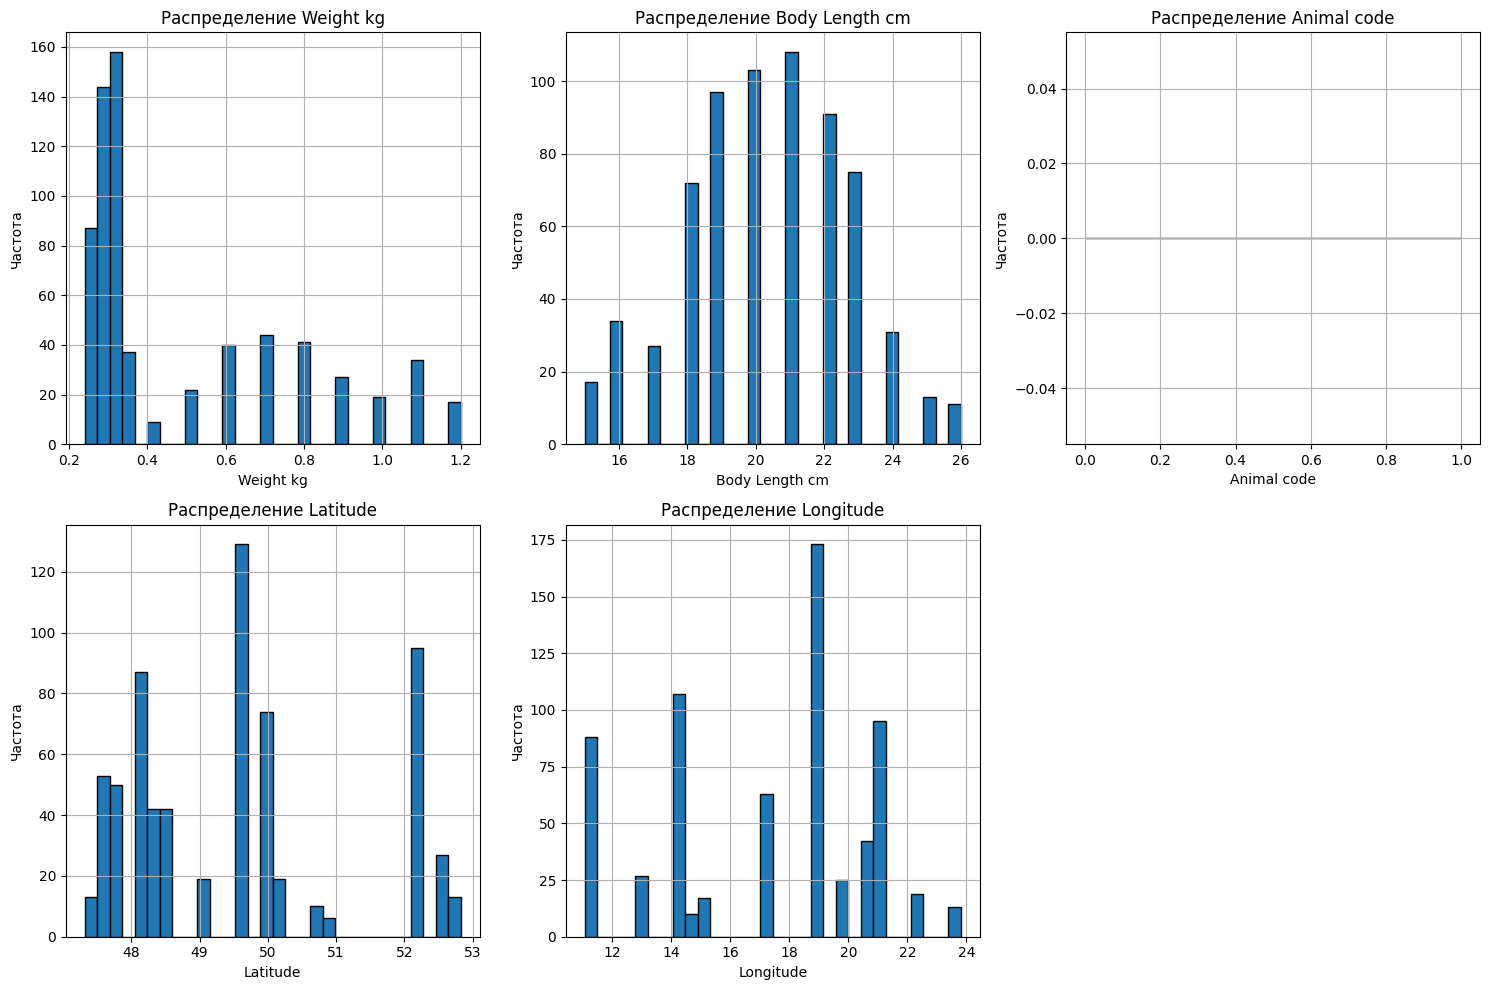

In [ ]:
print(f"Размер очищенного датасета: {df_animals.shape}")
print(f"Количество строк: {df_animals.shape[0]}")
print(f"Количество колонок: {df_animals.shape[1]}")

print("\nОсновные числовые характеристики (после очистки):")
numeric_cols = df_animals.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 0:
    print(df_animals[numeric_cols].describe())
    
    # Визуализация распределения числовых признаков
    if len(numeric_cols) > 0:
        n_cols = min(len(numeric_cols), 6)
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()
        
        for i, col in enumerate(numeric_cols[:n_cols]):
            df_animals[col].hist(bins=30, edgecolor='black', ax=axes[i])
            axes[i].set_title(f'Распределение {col}')
            axes[i].set_xlabel(col)
            axes[i].set_ylabel('Частота')
        
        # Скрываем пустые подграфики
        for i in range(len(numeric_cols[:n_cols]), len(axes)):
            axes[i].set_visible(False)
        
        plt.tight_layout()
        plt.show()
else:
    print("Нет числовых колонок для статистического описания")

# Задание: Анализ данных о фильмах

## 1. Загружаем данные

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

df_credits = pd.read_csv('credits.csv')
df_movies = pd.read_csv('movies_metadata.csv', low_memory=False)

print(f"Размер credits.csv: {df_credits.shape}")
print(f"Размер movies_metadata.csv: {df_movies.shape}")

# Предварительный просмотр данных
print("\nПервые 5 строк credits.csv:")
print(df_credits.head())

print("\nПервые 5 строк movies_metadata.csv:")
print(df_movies.head())

Размер credits.csv: (45476, 3)
Размер movies_metadata.csv: (45466, 24)

Первые 5 строк credits.csv:
                                                cast  \
0  [{'cast_id': 14, 'character': 'Woody (voice)',...   
1  [{'cast_id': 1, 'character': 'Alan Parrish', '...   
2  [{'cast_id': 2, 'character': 'Max Goldman', 'c...   
3  [{'cast_id': 1, 'character': "Savannah 'Vannah...   
4  [{'cast_id': 1, 'character': 'George Banks', '...   

                                                crew     id  
0  [{'credit_id': '52fe4284c3a36847f8024f49', 'de...    862  
1  [{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...   8844  
2  [{'credit_id': '52fe466a9251416c75077a89', 'de...  15602  
3  [{'credit_id': '52fe44779251416c91011acb', 'de...  31357  
4  [{'credit_id': '52fe44959251416c75039ed7', 'de...  11862  

Первые 5 строк movies_metadata.csv:
   adult                              belongs_to_collection    budget  \
0  False  {'id': 10194, 'name': 'Toy Story Collection', ...  30000000   
1  False

## 2. Создаем новый датасет с нужными полями

In [ ]:
# Преобразуем id в числовой формат для объединения
df_movies['id'] = pd.to_numeric(df_movies['id'], errors='coerce')
df_credits['id'] = pd.to_numeric(df_credits['id'], errors='coerce')

# Удаляем строки с NaN в id
df_movies = df_movies.dropna(subset=['id'])
df_credits = df_credits.dropna(subset=['id'])

# Объединяем датафреймы
df_merged = pd.merge(df_movies, df_credits, on='id', how='inner')

print(f"Размер объединенного датасета: {df_merged.shape}")

# Функция для извлечения режиссера из crew
def extract_director(crew_string):
    try:
        crew = eval(crew_string)  # Преобразуем строку в список словарей
        for member in crew:
            if member.get('job') == 'Director':
                return member.get('name')
    except:
        return None
    return None

# Функция для извлечения жанров
def extract_genres(genres_string):
    try:
        genres = eval(genres_string)  # Преобразуем строку в список словарей
        if genres and isinstance(genres, list):
            return [g['name'] for g in genres if 'name' in g]
    except:
        return []
    return []

# Применяем функции для создания новых колонок
print("\nИзвлечение информации о режиссерах и жанрах...")
df_merged['director'] = df_merged['crew'].apply(extract_director)
df_merged['genre_list'] = df_merged['genres'].apply(extract_genres)

# Создаем итоговый датасет
df_movies_final = df_merged[['title', 'director', 'genre_list', 'vote_average', 'vote_count']].copy()

# Разворачиваем список жанров - создаем отдельную строку для каждого жанра
df_exploded = df_movies_final.explode('genre_list')
df_exploded = df_exploded.rename(columns={'genre_list': 'genre'})

# Удаляем строки с отсутствующими значениями
df_exploded = df_exploded.dropna(subset=['director', 'genre', 'vote_average'])
df_exploded['vote_average'] = pd.to_numeric(df_exploded['vote_average'], errors='coerce')
df_exploded = df_exploded.dropna(subset=['vote_average'])

# Фильтруем фильмы с достаточным количеством голосов
df_exploded = df_exploded[df_exploded['vote_count'] > 10]

print(f"\nИтоговый датасет содержит {df_exploded.shape[0]} записей")
print("\nПервые 10 строк итогового датасета:")
print(df_exploded.head(10))

Размер объединенного датасета: (45538, 26)

Извлечение информации о режиссерах и жанрах...

Итоговый датасет содержит 50475 записей

Первые 10 строк итогового датасета:
               title         director      genre  vote_average  vote_count
0          Toy Story    John Lasseter  Animation           7.7      5415.0
0          Toy Story    John Lasseter     Comedy           7.7      5415.0
0          Toy Story    John Lasseter     Family           7.7      5415.0
1            Jumanji     Joe Johnston  Adventure           6.9      2413.0
1            Jumanji     Joe Johnston    Fantasy           6.9      2413.0
1            Jumanji     Joe Johnston     Family           6.9      2413.0
2   Grumpier Old Men    Howard Deutch    Romance           6.5        92.0
2   Grumpier Old Men    Howard Deutch     Comedy           6.5        92.0
3  Waiting to Exhale  Forest Whitaker     Comedy           6.1        34.0
3  Waiting to Exhale  Forest Whitaker      Drama           6.1        34.0


## 3. Анализ по режиссерам и жанрам


2.1 Статистика по режиссерам:

Всего режиссеров: 8796

Топ-10 режиссеров по количеству фильмов:
                   avg_rating  median_rating  rating_count  rating_std  \
director                                                                 
Alfred Hitchcock         6.92            7.1           121        0.81   
Woody Allen              6.71            6.7           111        0.56   
Clint Eastwood           6.51            6.5           101        0.68   
Steven Spielberg         6.87            7.0            86        0.70   
John Huston              6.69            6.5            81        0.63   
Takashi Miike            6.44            6.5            81        0.65   
Fritz Lang               6.96            7.1            80        0.72   
Sidney Lumet             6.48            6.6            79        0.79   
Steven Soderbergh        6.24            6.4            76        0.54   
Ridley Scott             6.62            6.5            74        0.77   

              

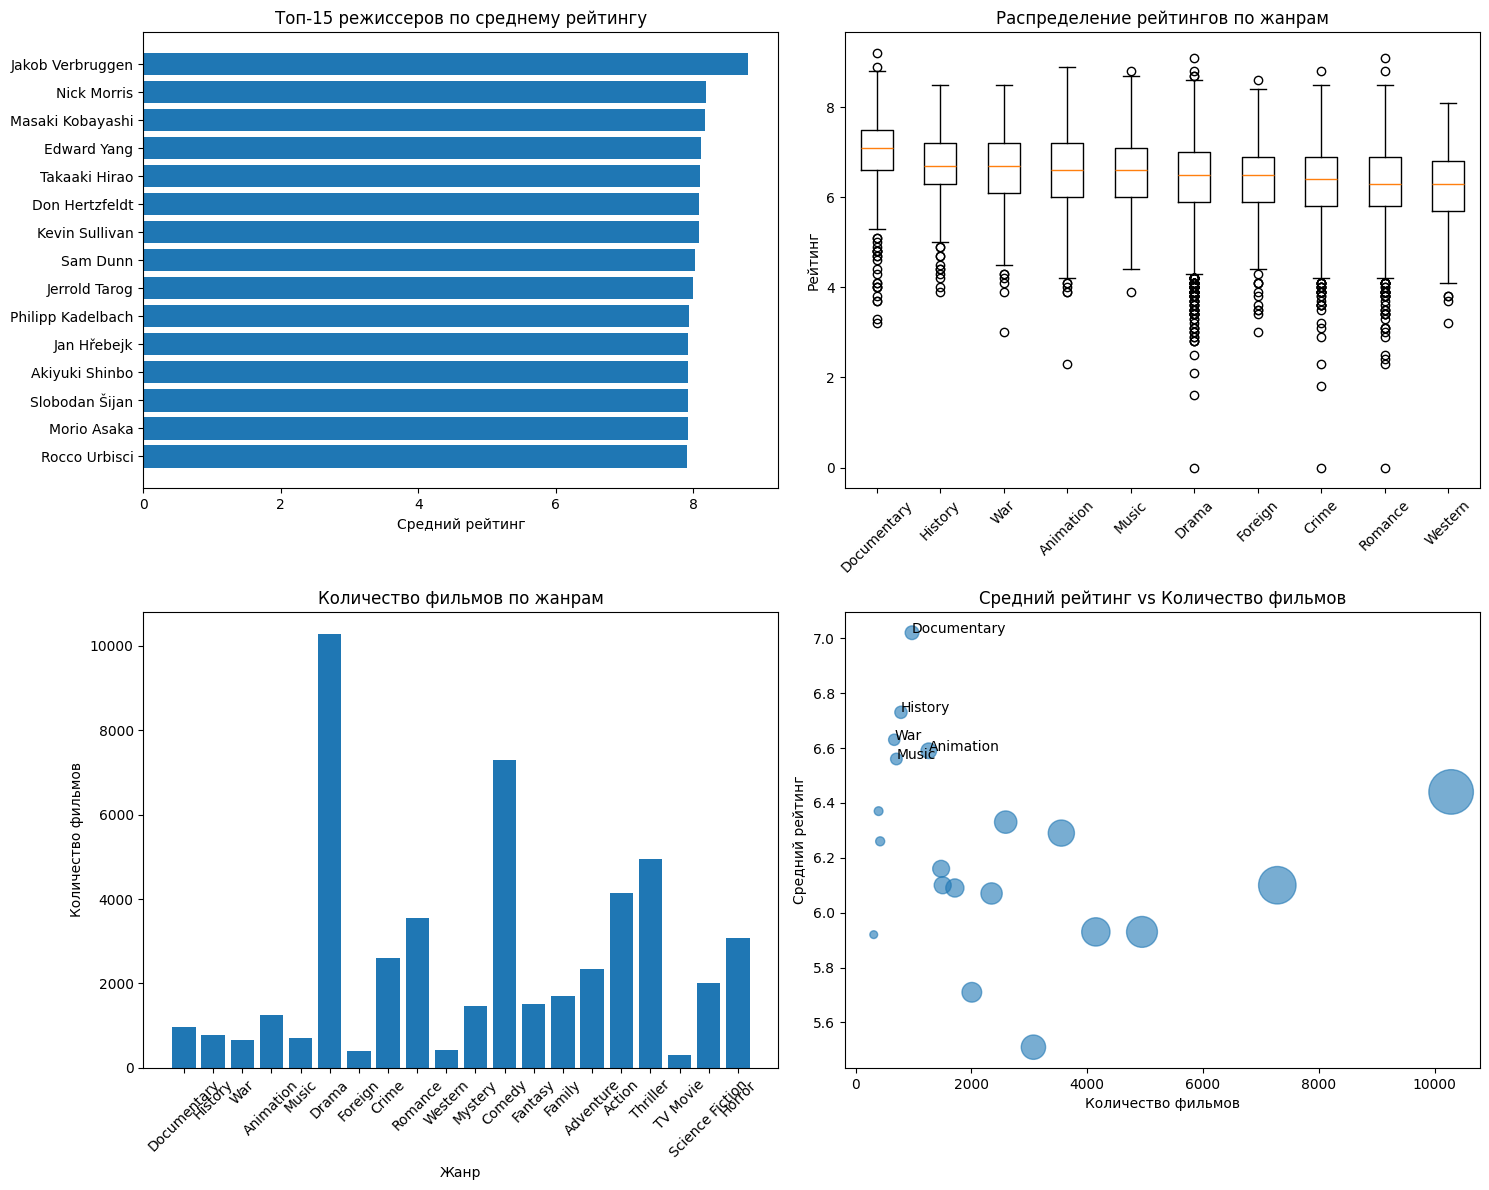


Самые высокооцененные фильмы по жанрам:

Documentary:
                        title     director  vote_average
                The Civil War    Ken Burns           9.2
        Bruce Lee: The Legend   Leonard Ho           8.9
The Story of Film: An Odyssey Mark Cousins           8.8

History:
                                      title         director  vote_average
     The Human Condition I: No Greater Love Masaki Kobayashi           8.5
   The Human Condition II: Road to Eternity Masaki Kobayashi           8.5
The Human Condition III: A Soldier's Prayer Masaki Kobayashi           8.4

War:
                                      title         director  vote_average
     The Human Condition I: No Greater Love Masaki Kobayashi           8.5
   The Human Condition II: Road to Eternity Masaki Kobayashi           8.5
The Human Condition III: A Soldier's Prayer Masaki Kobayashi           8.4

Animation:
                          title        director  vote_average
Kizumonogatari Part 2: Nekk

In [ ]:
# Анализ по режиссерам
print("\n2.1 Статистика по режиссерам:")
director_stats = df_exploded.groupby('director').agg({
    'vote_average': ['mean', 'median', 'count', 'std'],
    'title': 'count'
}).round(2)

director_stats.columns = ['avg_rating', 'median_rating', 'rating_count', 'rating_std', 'movie_count']
director_stats = director_stats.sort_values('movie_count', ascending=False)

print(f"\nВсего режиссеров: {len(director_stats)}")
print("\nТоп-10 режиссеров по количеству фильмов:")
print(director_stats.head(10))

# Режиссеры с самыми высокими оценками (минимум 5 фильмов)
top_directors = director_stats[director_stats['movie_count'] >= 5].sort_values('avg_rating', ascending=False)
print("\nТоп-10 режиссеров с самыми высокими средними оценками (минимум 5 фильмов):")
print(top_directors[['avg_rating', 'median_rating', 'movie_count']].head(10))

# Режиссеры с самыми низкими оценками
bottom_directors = director_stats[director_stats['movie_count'] >= 5].sort_values('avg_rating', ascending=True)
print("\nТоп-10 режиссеров с самыми низкими средними оценками (минимум 5 фильмов):")
print(bottom_directors[['avg_rating', 'median_rating', 'movie_count']].head(10))

# Анализ по жанрам
print("\n2.2 Статистика по жанрам:")
genre_stats = df_exploded.groupby('genre').agg({
    'vote_average': ['mean', 'median', 'count', 'std'],
    'title': 'count'
}).round(2)

genre_stats.columns = ['avg_rating', 'median_rating', 'rating_count', 'rating_std', 'movie_count']
genre_stats = genre_stats.sort_values('avg_rating', ascending=False)

print(f"\nВсего жанров: {len(genre_stats)}")
print("\nСтатистика по всем жанрам:")
print(genre_stats)

print("\nЖанры с самыми высокими средними оценками:")
print(genre_stats[['avg_rating', 'median_rating', 'movie_count']].head())

print("\nЖанры с самыми низкими средними оценками:")
print(genre_stats[['avg_rating', 'median_rating', 'movie_count']].tail())

# Визуализация результатов
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# График 1: Топ-15 режиссеров по среднему рейтингу
top_15_directors = top_directors.head(15)
axes[0, 0].barh(range(len(top_15_directors)), top_15_directors['avg_rating'].values)
axes[0, 0].set_yticks(range(len(top_15_directors)))
axes[0, 0].set_yticklabels(top_15_directors.index)
axes[0, 0].set_xlabel('Средний рейтинг')
axes[0, 0].set_title('Топ-15 режиссеров по среднему рейтингу')
axes[0, 0].invert_yaxis()

# График 2: Распределение рейтингов по жанрам (ИСПРАВЛЕНО)
genre_data = []
top_10_genres = genre_stats.index[:10]  # Топ-10 жанров
for genre in top_10_genres:
    genre_data.append(df_exploded[df_exploded['genre'] == genre]['vote_average'].values)

# Убираем параметр rot и устанавливаем rotation отдельно
boxplot = axes[0, 1].boxplot(genre_data, labels=top_10_genres)
axes[0, 1].set_ylabel('Рейтинг')
axes[0, 1].set_title('Распределение рейтингов по жанрам')
axes[0, 1].tick_params(axis='x', rotation=45)  # Устанавливаем поворот меток здесь

# График 3: Количество фильмов по жанрам
axes[1, 0].bar(genre_stats.index, genre_stats['movie_count'].values)
axes[1, 0].set_xlabel('Жанр')
axes[1, 0].set_ylabel('Количество фильмов')
axes[1, 0].set_title('Количество фильмов по жанрам')
axes[1, 0].tick_params(axis='x', rotation=45)

# График 4: Средний рейтинг vs Количество фильмов по жанрам
scatter = axes[1, 1].scatter(genre_stats['movie_count'], genre_stats['avg_rating'], 
                            s=genre_stats['rating_count']/10, alpha=0.6)
axes[1, 1].set_xlabel('Количество фильмов')
axes[1, 1].set_ylabel('Средний рейтинг')
axes[1, 1].set_title('Средний рейтинг vs Количество фильмов')

# Добавляем подписи для некоторых жанров
for genre in genre_stats.index[:5]:
    axes[1, 1].annotate(genre, 
                       (genre_stats.loc[genre, 'movie_count'], 
                        genre_stats.loc[genre, 'avg_rating']))

plt.tight_layout()
plt.show()

# Детальный анализ
# Самые высокооцененные фильмы по жанрам
print("\nСамые высокооцененные фильмы по жанрам:")
for genre in genre_stats.index[:5]:  # Топ-5 жанров
    top_movies = df_exploded[df_exploded['genre'] == genre].nlargest(3, 'vote_average')[['title', 'director', 'vote_average']]
    print(f"\n{genre}:")
    print(top_movies.to_string(index=False))

# Статистика по режиссерам с наибольшим количеством фильмов
print("\nРежиссеры с наибольшим количеством фильмов:")
top_by_volume = director_stats.nlargest(10, 'movie_count')[['movie_count', 'avg_rating']]
print(top_by_volume.to_string())

In [ ]:
# Сохранение итогового датасета
df_exploded.to_csv('movies_directors_genres.csv', index=False)
print("Датасет сохранен в файл movies_directors_genres.csv")

Датасет сохранен в файл movies_directors_genres.csv
